# 💎 Diamond Dynamics — Notebook 04: Regression Models
---
## Objective
Build and evaluate multiple ML regression models to predict diamond price in INR.

## Models Built
1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor  ← Best Model
4. KNN Regressor
5. XGBoost Regressor

## Evaluation Metrics
MAE, MSE, RMSE, R²

## Input  → data/diamonds_engineered.csv
## Output → models/best_regression_model.pkl, models/scaler.pkl

#  Import & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/diamonds_engineered.csv')
print('Data loaded:', df.shape)

Data loaded: (53794, 25)


# Select Features for Regression

In [4]:
# Features for regression — using log transformed target (log_price_inr)
features = ['log_carat', 'cut_encoded', 'color_encoded', 'clarity_encoded',
            'depth', 'table', 'x', 'y', 'z', 'volume', 
            'price_per_carat', 'dimension_ratio']

target = 'log_price_inr'

X = df[features]
y = df[target]

print('Features:', X.shape)
print('Target:', y.shape)
print('\nFeature columns:')
print(features)

Features: (53794, 12)
Target: (53794,)

Feature columns:
['log_carat', 'cut_encoded', 'color_encoded', 'clarity_encoded', 'depth', 'table', 'x', 'y', 'z', 'volume', 'price_per_carat', 'dimension_ratio']


# Train Test Split & Scaling

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save scaler
joblib.dump(scaler, '../models/scaler.pkl')

print(f'Train size: {X_train.shape}')
print(f'Test size : {X_test.shape}')
print('Scaler saved ')

Train size: (43035, 12)
Test size : (10759, 12)
Scaler saved 


# Helper Function for Evaluation

In [11]:
def evaluate_model(name, y_test, y_pred):
    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)
    print(f'\n--- {name} ---')
    print(f'MAE  : {mae:.4f}')
    print(f'MSE  : {mse:.4f}')
    print(f'RMSE : {rmse:.4f}')
    print(f'R²   : {r2:.4f}')
    return {'Model': name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

results = []  # store all model results here

# Linear Regression

In [14]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
results.append(evaluate_model('Linear Regression', y_test, y_pred_lr))


--- Linear Regression ---
MAE  : 0.0702
MSE  : 0.0123
RMSE : 0.1109
R²   : 0.9877


# Decision Tree

In [17]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)
results.append(evaluate_model('Decision Tree', y_test, y_pred_dt))


--- Decision Tree ---
MAE  : 0.0058
MSE  : 0.0004
RMSE : 0.0188
R²   : 0.9996


# Random Forest

In [20]:
# n_estimators=100 is good balance of speed vs accuracy
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
results.append(evaluate_model('Random Forest', y_test, y_pred_rf))


--- Random Forest ---
MAE  : 0.0036
MSE  : 0.0002
RMSE : 0.0133
R²   : 0.9998


# KNN

In [23]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
results.append(evaluate_model('KNN', y_test, y_pred_knn))


--- KNN ---
MAE  : 0.0656
MSE  : 0.0086
RMSE : 0.0929
R²   : 0.9914


#  XGBoost

In [26]:
xgb = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)
results.append(evaluate_model('XGBoost', y_test, y_pred_xgb))


--- XGBoost ---
MAE  : 0.0096
MSE  : 0.0002
RMSE : 0.0157
R²   : 0.9998


# Compare All Models

In [29]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R2', ascending=False).reset_index(drop=True)
print(results_df)

               Model       MAE       MSE      RMSE        R2
0      Random Forest  0.003618  0.000177  0.013286  0.999824
1            XGBoost  0.009564  0.000247  0.015717  0.999754
2      Decision Tree  0.005785  0.000353  0.018783  0.999648
3                KNN  0.065602  0.008634  0.092921  0.991390
4  Linear Regression  0.070226  0.012290  0.110858  0.987745


#  Visualize Model Comparison

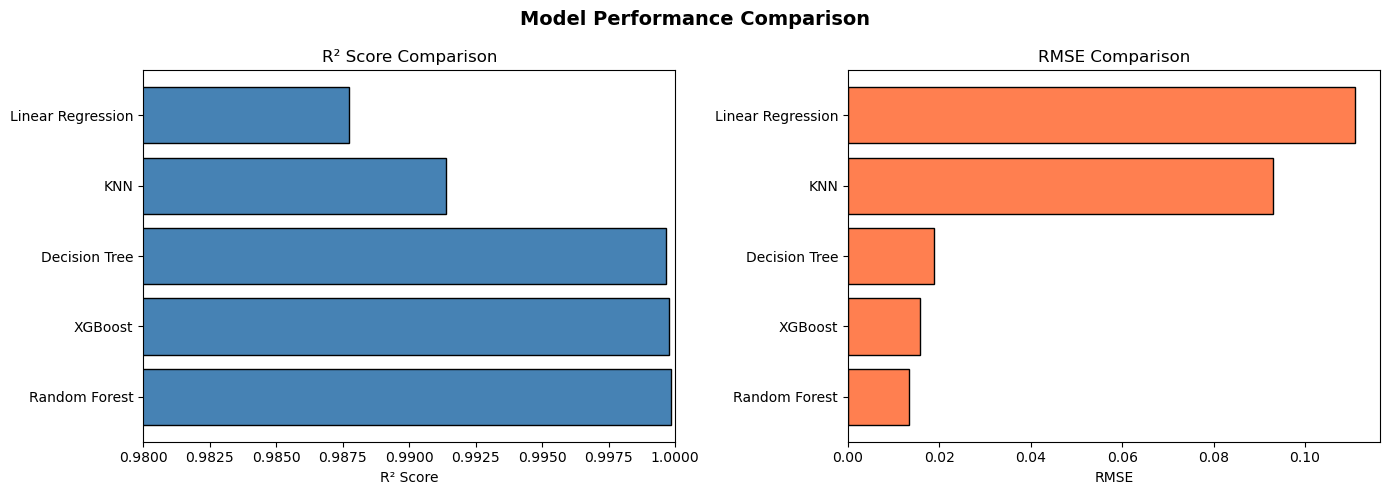

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R2 comparison
axes[0].barh(results_df['Model'], results_df['R2'], color='steelblue', edgecolor='black')
axes[0].set_title('R² Score Comparison')
axes[0].set_xlabel('R² Score')
axes[0].set_xlim(0.98, 1.0)

# RMSE comparison
axes[1].barh(results_df['Model'], results_df['RMSE'], color='coral', edgecolor='black')
axes[1].set_title('RMSE Comparison')
axes[1].set_xlabel('RMSE')

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Save Best Model (Random Forest)

In [35]:
# Random Forest has lowest RMSE — save as best model
joblib.dump(rf, '../models/best_regression_model.pkl')
print('Best model (Random Forest) saved ')
print('Location: ../models/best_regression_model.pkl')

Best model (Random Forest) saved 
Location: ../models/best_regression_model.pkl


# Feature Importance

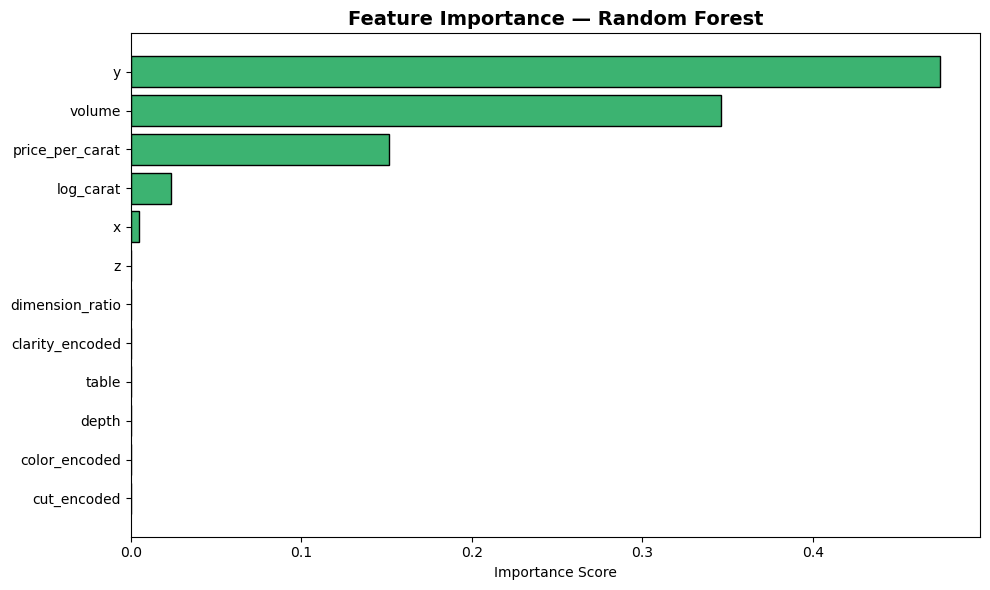

            Feature  Importance
7                 y    0.474249
9            volume    0.345825
10  price_per_carat    0.151575
0         log_carat    0.023550
6                 x    0.004634
8                 z    0.000102
11  dimension_ratio    0.000020
3   clarity_encoded    0.000015
5             table    0.000008
4             depth    0.000008
2     color_encoded    0.000008
1       cut_encoded    0.000006


In [38]:
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='mediumseagreen', edgecolor='black')
plt.title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(importance_df)